In [4]:
import phoenix
import json
import numpy as np
import time

In [5]:
# json_fname = './benchmarks/hamlib_json/chemistry/N2-JW-22.json'
# json_fname = './benchmarks/hamlib_json/chemistry/NH-BK-14.json'
# json_fname = './benchmarks/hamlib_json/condensedmatter/FH_D-1-fh-graph-1D-grid-pbc-qubitnodes_Lx-160_U-12_enc-parity.json'
# json_fname = './benchmarks/hamlib_json/discreteoptimization/gray-color02-1-fullins_5_k-5-1-fullins_5.json'
# json_fname = './benchmarks/hamlib_json/discreteoptimization/gray-color02-will199gpia_k-3-will199gpia.json'
json_fname = './benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-10-tsp_prob-pr76_Ncity-10_enc-unary.json'
# json_fname = './benchmarks/hamlib_json/discreteoptimization/gray-color02-1-fullins_5_k-5-1-fullins_5.json'


with open(json_fname, 'r') as f:
    data = json.load(f)

M = -1
ham = phoenix.Hamiltonian(data['paulis'][:M], data['coeffs'][:M])
grouped_hams = ham.group_same_weights()

FileNotFoundError: [Errno 2] No such file or directory: './benchmarks/hamlib_json/discreteoptimization/TSP_Ncity-10-tsp_prob-pr76_Ncity-10_enc-unary.json'

In [ ]:
ham.max_weight

np.int64(2)

In [3]:
phoenix.utils.print_circ_info(ham.generate_circuit())

NameError: name 'ham' is not defined

In [5]:
qc = phoenix.utils.compile_by_tket(ham.paulis.to_labels(), ham.coeffs)
phoenix.utils.print_circ_info(qc)


+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|    100     |    3060   |     1985     |  328  |   309    |
+------------+-----------+--------------+-------+----------+


In [6]:
qc = phoenix.utils.compile_by_qiskit(ham.paulis.to_labels(), ham.coeffs)
phoenix.utils.print_circ_info(qc)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|    100     |    2690   |     1691     |  667  |   486    |
+------------+-----------+--------------+-------+----------+


In [7]:
qc = phoenix.compile_hamiltonian_simulation(ham, grouping='support')
phoenix.utils.print_circ_info(qc)

+------------+-----------+--------------+-------+----------+
| num_qubits | num_gates | num_2q_gates | depth | depth_2q |
+------------+-----------+--------------+-------+----------+
|    100     |    5500   |     1800     |   93  |    46    |
+------------+-----------+--------------+-------+----------+


In [5]:
len(grouped_hams)

1576

In [3]:
grouped_hams

[SparsePauliOp(['XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'YXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

In [4]:
len(grouped_hams)

10

In [5]:
[data['num_qubits'] - p.count('I') for p in data['paulis'][:M]]

[1, 360, 10, 5, 2, 359, 9, 4, 359, 9, 3, 1, 357, 7, 357, 7, 3, 1, 355, 5]

In [6]:
phoenix.primitive.group_paulis(data['paulis'][:M])

{(np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8),
  np.int64(9),
  np.int64(10),
  np.int64(11),
  np.int64(12),
  np.int64(13),
  np.int64(14),
  np.int64(15),
  np.int64(16),
  np.int64(17),
  np.int64(18),
  np.int64(19),
  np.int64(20),
  np.int64(21),
  np.int64(22),
  np.int64(23),
  np.int64(24),
  np.int64(25),
  np.int64(26),
  np.int64(27),
  np.int64(28),
  np.int64(29),
  np.int64(30),
  np.int64(31),
  np.int64(32),
  np.int64(33),
  np.int64(34),
  np.int64(35),
  np.int64(36),
  np.int64(37),
  np.int64(38),
  np.int64(39),
  np.int64(40),
  np.int64(41),
  np.int64(42),
  np.int64(43),
  np.int64(44),
  np.int64(45),
  np.int64(46),
  np.int64(47),
  np.int64(48),
  np.int64(49),
  np.int64(50),
  np.int64(51),
  np.int64(52),
  np.int64(53),
  np.int64(54),
  np.int64(55),
  np.int64(56),
  np.int64(57),
  np.int64(58),
  np.int64(59),
  np.int64(60),
  np.int64(61),
  np.int64(62),
  

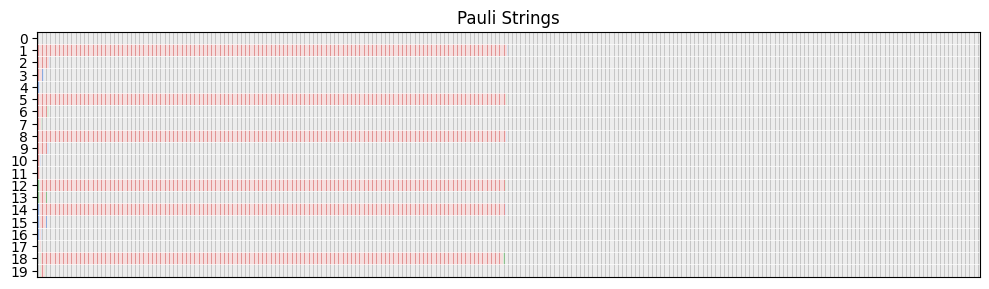

In [7]:
phoenix.utils.plot_pauli_strings(data['paulis'][:M], figsize=(10, 3), hide_axis=True)

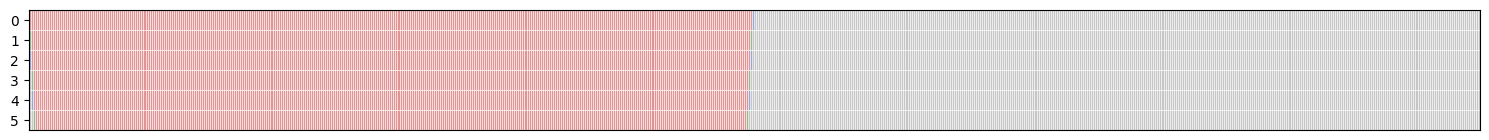

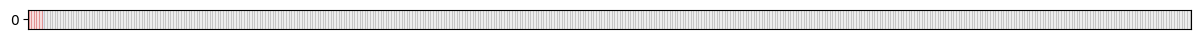

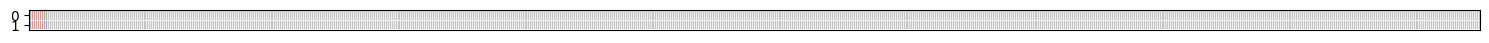

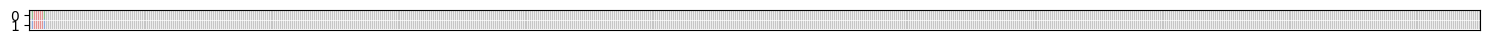

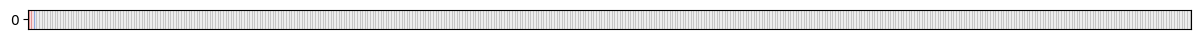

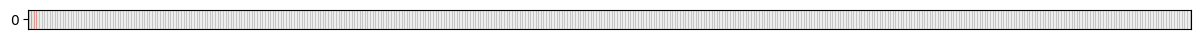

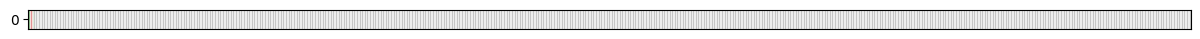

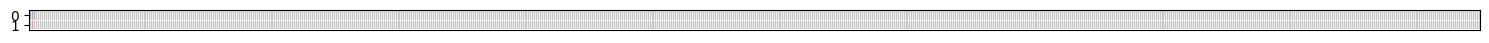

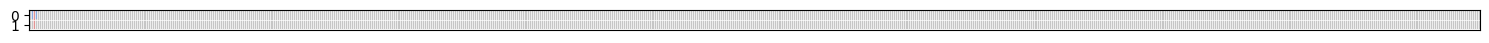

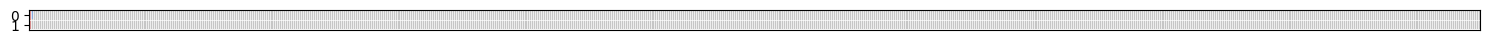

In [10]:
for ham in grouped_hams:
    phoenix.utils.plot_pauli_strings(ham.paulis.to_labels(), figsize=(15, ham.size / 4), hide_axis=True, title='')

In [11]:
ham = grouped_hams[0]

In [13]:
phoenix.primitive.heuristic_bsf_cost(ham.paulis.x, ham.paulis.z)

np.float64(21055.0)

In [29]:
costs = []
for p in ham.paulis:
    c = phoenix.primitive.heuristic_bsf_cost(p.x.reshape(1, -1), p.z.reshape(1, -1))
    costs.append(c)
print(costs)

[np.float64(360.0), np.float64(359.0), np.float64(359.0), np.float64(357.0), np.float64(357.0), np.float64(355.0)]


In [31]:
np.sum(costs)

np.float64(2147.0)

In [46]:
p_0 = grouped_hams[0].paulis[0]
p_1 = grouped_hams[0].paulis[1]
p_last = grouped_hams[-1].paulis[0]

c_0 = phoenix.primitive.heuristic_bsf_cost(p_0.x.reshape(1, -1), p_0.z.reshape(1, -1))
c_last = phoenix.primitive.heuristic_bsf_cost(p_last.x.reshape(1, -1), p_last.z.reshape(1, -1))


In [47]:
p_comb = phoenix.Hamiltonian([p_0, p_last]).paulis
c_comb = phoenix.primitive.heuristic_bsf_cost(p_comb.x, p_comb.z)
print(c_0, c_last, c_comb)

360.0 2.0 1980.5


In [48]:
p_comb = phoenix.Hamiltonian([p_0, p_1]).paulis
c_comb = phoenix.primitive.heuristic_bsf_cost(p_comb.x, p_comb.z)
print(c_0, c_last, c_comb)

360.0 2.0 1981.0


In [50]:
p_1

Pauli('YXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...')

In [51]:
p_last

Pauli('XZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...')